# Introducción a los algoritmos genéticos (Optimización)

In [2]:
import random
import math
import numpy as np
from deap import base
from deap import creator
from deap import tools
from deap import algorithms
from matplotlib import cm
import matplotlib.pyplot as plt 

Text(0.5, 0, 'f(x, y)')

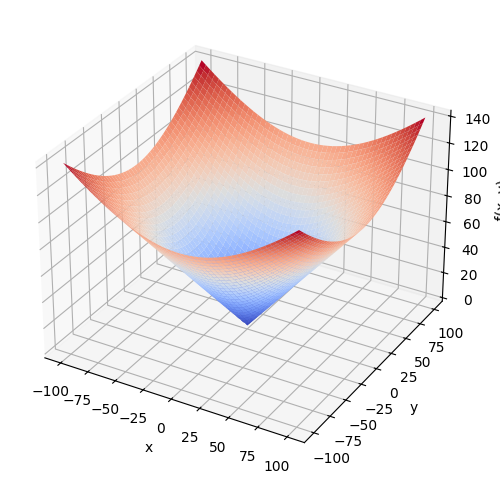

In [4]:
# Definimos la funcion objetivo
def funcion_prueba(x):
    res = np.sqrt(x[0] ** 2 + x[1] ** 2)
    return res

# Se generan vectores que borran todo el dominio
x = np.linspace(-100, 100, 1000)
y = np.linspace(-100, 100, 1000)

# Se evalua todos los valores de las variables 
x_ax, y_ax = np.meshgrid(x, y)
vals = np.c_ [x_ax.ravel(), y_ax.ravel()]
fx = np.reshape([funcion_prueba(val) for val in vals], (1000, 1000))

# Representamos los resultados obtenidos
figure_3d = plt.figure(figsize = (8, 6))
ax = figure_3d.add_subplot(111, projection = "3d")

ax.plot_surface(x_ax, y_ax, fx, cmap = cm.coolwarm)
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_zlabel("f(x, y)")


In [14]:
# Creacion del problema
creator.create("FitnessMax", base.Fitness, weights = (1.0, ))

c:\Users\migue\OneDrive\Escritorio\Ingenieria en tecnologias de la información\Octavo semestre\.venv\Lib\site-packages\deap\creator.py:185: RuntimeWarning: A class named 'FitnessMax' has already been created and it will be overwritten. Consider deleting previous creation of that class or rename it.
  warnings.warn("A class named '{0}' has already been created and it "


In [15]:
# Creacion del individuo
creator.create("Individual", list, fitness = creator.FitnessMax)

c:\Users\migue\OneDrive\Escritorio\Ingenieria en tecnologias de la información\Octavo semestre\.venv\Lib\site-packages\deap\creator.py:185: RuntimeWarning: A class named 'Individual' has already been created and it will be overwritten. Consider deleting previous creation of that class or rename it.
  warnings.warn("A class named '{0}' has already been created and it "


In [ ]:
# Crear individuos aleatorios
toolbox = base.Toolbox() # Creacion de individuos aleatorios para crear la poblacion inicial

# Generacion de genes 
toolbox.register("attr_uniform", random.uniform, -100, 100)
toolbox.register("individual", tools.initRepeat, creator.Individual, toolbox.attr_uniform, 2)

# Se crea la poblacion inicial con 10 individuos
toolbox.register("population", tools.initRepeat, list, toolbox.individual, 10)

In [21]:
# Definicio de la funcion objetivo
def funcion_objetivo(x):
    for i in range(len(x)):
        if x[i] > 100 or x[i] < -100:
            return -1,
    res = math.sqrt(x[0] ** 2 + x[1] ** 2)
    return res,

# Aplicacion del fitness
toolbox.register("evaluate", funcion_objetivo)

In [22]:
# Operadores geneticos
toolbox.register("mate", tools.cxOnePoint)
'''
mu: La media
sigma: Desviación tipica
indpb: Probabilidad de que un gen mute
'''
toolbox.register("mutate", tools.mutGaussian, mu = 0, sigma = 5, indpb = 0.1)
toolbox.register("select", tools.selTournament, tournsize = 3)

In [23]:
# Convergencia del algoritmo 
def plot_evolucion(log):
    gen = np.array(log.select("gen"))
    fit_mins = np.array(log.select("min"), dtype = float)
    fit_maxs = np.array(log.select("max"), dtype = float)
    fit_ave = np.array(log.select("avg"), dtype = float)

    fig, ax1 = plt.subplots()
    ax1.plot(gen, fit_mins, "b")
    ax1.plot(gen, fit_maxs, "r")
    ax1.plot(gen, fit_ave, "--k")
    where_mask = fit_maxs >= fit_mins
    ax1.fill_between(gen, fit_mins, fit_maxs, where = where_mask, facecolor = 'g', alpha = 0.2)
    ax1.set_xlabel("Generation")
    ax1.set_ylabel("Fitness")
    ax1.set_ylim([-10, 160])
    ax1.legend(["Min", "Max", "Avg"], loc = "lower center")
    plt.grid(True)
    plt.savefig("Convergencia.eps", dpi = 300)

gen	nevals	avg    	std   	min    	max    
0  	10    	81.3622	28.287	31.2954	116.497
1  	2     	108.322	14.1648	71.337 	126.071
2  	7     	116.868	9.20852	98.8946	136.779
3  	4     	121.084	8.49836	112.226	136.779
4  	7     	125.454	8.40708	116.497	136.779
5  	4     	135.519	3.19937	126.071	136.779
6  	5     	136.779	0      	136.779	136.779
7  	5     	136.779	0      	136.779	136.779
8  	10    	136.779	0      	136.779	136.779
9  	4     	136.358	1.26178	132.573	136.779
10 	6     	136.779	0      	136.779	136.779
11 	6     	136.779	0      	136.779	136.779
12 	7     	136.779	0      	136.779	136.779
13 	7     	136.779	0      	136.779	136.779
14 	8     	122.639	41.2271	-1     	136.779
15 	6     	136.779	0      	136.779	136.779
16 	5     	136.779	0      	136.779	136.779
17 	6     	136.779	0      	136.779	136.779
18 	6     	136.779	0      	136.779	136.779
19 	6     	136.452	0.980645	133.51 	136.779
20 	4     	136.779	0       	136.779	136.779
Mejor fitness: 136.778896
Mejor individuo: [-94.692806

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


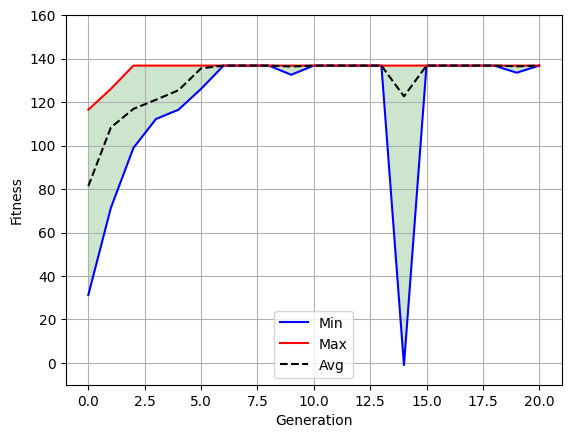

In [24]:
# Configuracion del algoritmo genetico
def main():
    random.seed(42) # Semilla del generadore de los numeros pseudoaleatorios
    CXPB, MUTPB, NGEN = 0.5, 0.2, 20 # Probabilidades de cruza, mutacion y numero de generaciones
    pop = toolbox.population() # Generacion de la poblacion inicial
    hof = tools.HallOfFame(1) # Almacena al mejor individuo encontrado en todas las generaciones
    stats = tools.Statistics(lambda ind: ind.fitness.values) # Genera las estadisticas de población sobre el fitness
    stats.register("avg", np.mean) # Calcular la media
    stats.register("std", np.std) # Desviación estandar tipica
    stats.register("min", np.min) # Valor minimo absoluto de la generación
    stats.register("max", np.max) # Valor maximo absoluto de la generación
    logbook = tools.Logbook()
    pop, logbook = algorithms.eaSimple(pop, toolbox, cxpb = CXPB, mutpb = MUTPB, ngen = NGEN, stats = stats, halloffame = hof, verbose = True)
    return hof, logbook

if __name__ == "__main__":
    best, log = main()
    print("Mejor fitness: %f" %best[0].fitness.values)
    print("Mejor individuo: %s" %best[0])
    plot_evolucion(log)

In [25]:
# Prueba cpn 30 individuos
toolbox.register("population", tools.initRepeat, list, toolbox.individual, 30)
toolbox.register("evaluate", funcion_objetivo)
toolbox.register("mate", tools.cxOnePoint)
toolbox.register("mutate", tools.mutGaussian, mu = 0, sigma = 5, indpb = 0.1)
toolbox.register("select", tools.selTournament, tournsize = 3)

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


gen	nevals	avg    	std   	min    	max    
0  	30    	77.9162	24.544	26.4289	116.497
1  	15    	98.1576	15.6516	58.7221	123.194
2  	18    	108.641	17.0172	47.071 	131.857
3  	24    	122.041	7.64215	99.9797	134.549
4  	19    	128.584	3.92487	122.005	134.549
5  	11    	132.005	2.13284	125.135	134.549
6  	22    	133.419	1.60997	131.169	136.779
7  	20    	130.449	24.4622	-1     	136.779
8  	17    	136.143	1.12918	133.455	137.464
9  	16    	136.686	0.662231	134.132	137.486
10 	14    	137.114	0.611792	136.779	139.908
11 	15    	137.235	1.30432 	131.674	139.908
12 	23    	137.979	0.981347	137.464	140.041
13 	21    	133.762	25.0534 	-1     	140.101
14 	17    	138.776	1.53284 	133.594	140.101
15 	15    	130.265	35.0922 	-1     	140.101
16 	15    	140.042	0.0666659	139.908	140.101
17 	15    	140.024	0.334088 	138.242	140.101
18 	18    	140.101	5.68434e-14	140.101	140.101
19 	20    	140.021	0.347706   	138.217	140.101
20 	20    	140.067	0.183959   	139.076	140.101
Mejor fitness: 140.100794
Mejor i

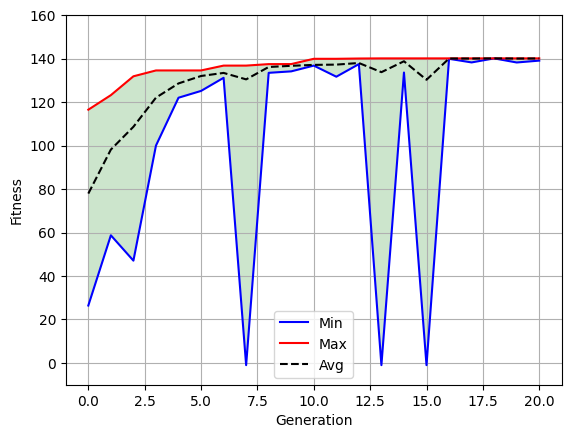

In [26]:
best, log = main()
print("Mejor fitness: %f" %best[0].fitness.values)
print("Mejor individuo: %s" %best[0])
plot_evolucion(log)

In [27]:
# Prueba cpn 50 individuos
toolbox.register("population", tools.initRepeat, list, toolbox.individual, 50)
toolbox.register("evaluate", funcion_objetivo)
toolbox.register("mate", tools.cxOnePoint)
toolbox.register("mutate", tools.mutGaussian, mu = 0, sigma = 5, indpb = 0.1)
toolbox.register("select", tools.selTournament, tournsize = 3)

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


gen	nevals	avg    	std    	min    	max    
0  	50    	79.5138	24.5664	26.4289	122.059
1  	28    	97.8301	18.6489	48.4558	130.873
2  	28    	115.187	13.6357	83.2838	140.132
3  	40    	124.553	19.4919	-1     	136.574
4  	27    	133.61 	3.47646	119.014	140.132
5  	37    	135.631	2.05285	130.873	140.132
6  	30    	134.284	19.451 	-1     	140.132
7  	29    	135.773	19.6169	-1     	140.132
8  	34    	137.125	19.7385	-1     	140.132
9  	30    	140.118	0.191669	138.887	140.677
10 	28    	140.138	0.309691	138.232	140.677
11 	30    	140.176	0.147685	140.132	140.677
12 	27    	140.263	0.232492	140.132	140.677
13 	32    	137.339	19.7939 	-1     	140.677
14 	29    	140.545	0.26766 	139.41 	140.677
15 	28    	140.668	0.0591235	140.254	140.677
16 	29    	137.843	19.8347  	-1     	140.677
17 	31    	140.561	0.810355 	134.888	140.677
18 	28    	140.514	0.830834 	135.436	140.677
19 	34    	140.677	0        	140.677	140.677
20 	25    	137.843	19.8347  	-1     	140.677
Mejor fitness: 140.676643
Mejor indi

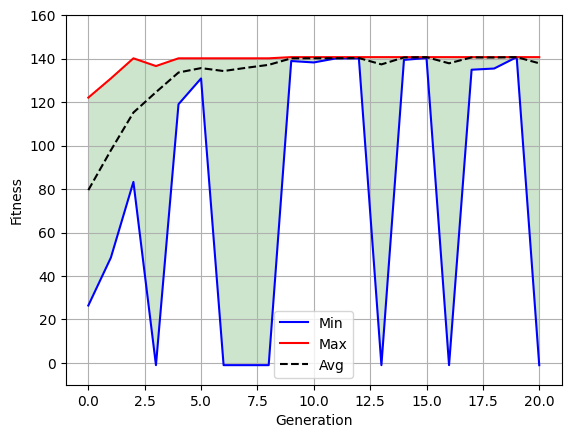

In [28]:
best, log = main()
print("Mejor fitness: %f" %best[0].fitness.values)
print("Mejor individuo: %s" %best[0])
plot_evolucion(log)